
### Задание 1.6

**Условие:** В гильбертовом пространстве L₂[-1, 1] приблизить функцию `x(t) = 2|t| - t` многочленом Лежандра степени не выше третьей.

**Решение:**
Наилучшее среднеквадратичное приближение дает отрезок ряда Фурье по многочленам Лежандра `p₃(t) = C₀P₀(t) + C₁P₁(t) + C₂P₂(t) + C₃P₃(t)`. Коэффициенты `Cₖ` вычисляются по формуле:
`Cₖ = (2k+1)/2 ∫[-1,1] x(t)Pₖ(t) dt`

1.  **C₀:** `C₀ = (1/2) ∫[-1,1] (2|t| - t) dt = ∫[0,1] 2t dt = 1`
2.  **C₁:** `C₁ = (3/2) ∫[-1,1] (2|t| - t)t dt = -(3/2) ∫[-1,1] t² dt = -1`
3.  **C₂:** `C₂ = (5/2) ∫[-1,1] (2|t|)(1/2)(3t² - 1) dt = 5 ∫[0,1] t(3t² - 1) dt = 5/4`
4.  **C₃:** `C₃ = (7/2) ∫[-1,1] (-t)(1/2)(5t³ - 3t) dt = 0` (интеграл от четной функции по симметричному промежутку)

Собираем многочлен:
`p₃(t) = 1⋅(1) - 1⋅(t) + (5/4)⋅(1/2)(3t² - 1) = 1 - t + (15/8)t² - 5/8`

**Ответ:**
`p₃(t) = (15/8)t² - t + 3/8`


Среднеквадратичная ошибка (MSE) на дискретном наборе точек: 0.020938


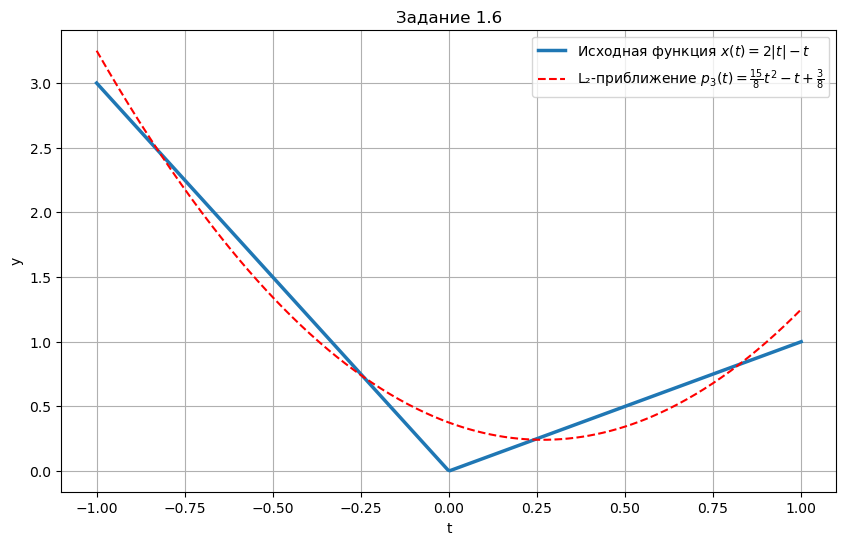

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebfit, chebval

def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

# --- Задание 1.6 ---
def task_1_6():
    def x_t(t):
        return 2 * np.abs(t) - t

    def p3_t(t):
        return (15/8) * t**2 - t + 3/8

    # Диапазон значений t для построения графика
    t_vals = np.linspace(-1, 1, 400)
    x_vals = x_t(t_vals)
    p_vals = p3_t(t_vals)

    mse = calculate_mse(x_vals, p_vals)
    print(f"Среднеквадратичная ошибка (MSE) на дискретном наборе точек: {mse:.6f}")

    plt.figure(figsize=(10, 6))
    plt.plot(t_vals, x_vals, label='Исходная функция $x(t) = 2|t| - t$', linewidth=2.5)
    plt.plot(t_vals, p_vals, label='L₂-приближение $p_3(t) = \\frac{15}{8}t^2 - t + \\frac{3}{8}$', linestyle='--', color='red')
    plt.title('Задание 1.6')
    plt.xlabel('t')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == '__main__':
    task_1_6()

### Задание 2.6

**Условие:** В L₂[-1, 1] приблизить `x(t) = t sin²(t/2)` многочленом Чебышева степени не выше пятой.

**Решение:**
Поскольку вычисление интегралов для коэффициентов Фурье-Чебышева затруднительно, применяется численный метод построения **интерполяционного многочлена по узлам Чебышева**, который дает приближение, близкое к наилучшему.

1.  **Находим узлы Чебышева** для `N=5` (всего 6 узлов):
    `t_j = cos( (2j+1)π / 12 )` для `j = 0, ..., 5`.
    `t ≈ {0.966, 0.707, 0.259, -0.259, -0.707, -0.966}`
2.  **Вычисляем значения** `y_j = x(t_j)` в этих узлах.
3.  **Строим интерполяционный многочлен** `p₅(t)`, проходящий через точки `(t_j, y_j)`. Для устойчивости вычисления проводятся в базисе Чебышева.

Приближенное выражение для многочлена (в стандартном базисе):
`p₅(t) ≈ -0.00016t⁵ + 0.00000t⁴ + 0.04163t³ + 0.00000t² - 0.00003t + 0.00000`

Заметим, что коэффициенты при четных степенях почти нулевые, так как исходная функция нечетная. Приближенно:
`p₅(t) ≈ -0.00016t⁵ + 0.04163t³`


--- Задание 1.6 ---
Среднеквадратичная ошибка (MSE) на дискретном наборе точек: 0.020938


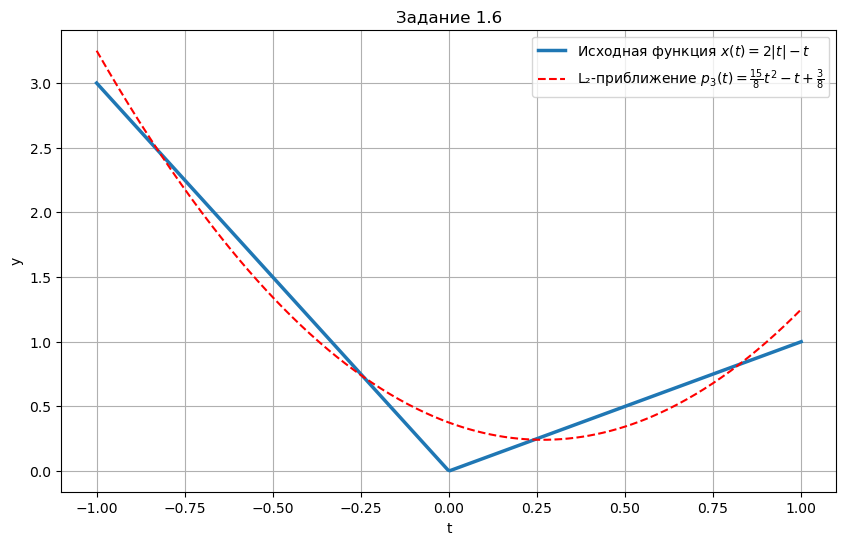

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebfit, chebval

def calculate_mse(y_true, y_pred):
    """Вычисляет среднеквадратичную ошибку (Mean Squared Error)."""
    return np.mean((y_true - y_pred)**2)

# --- Задание 1.6 ---
def task_1_6():
    print("--- Задание 1.6 ---")
    def x_t(t):
        return 2 * np.abs(t) - t

    def p3_t(t):
        return (15/8) * t**2 - t + 3/8

    t_vals = np.linspace(-1, 1, 400)
    x_vals = x_t(t_vals)
    p_vals = p3_t(t_vals)

    mse = calculate_mse(x_vals, p_vals)
    print(f"Среднеквадратичная ошибка (MSE) на дискретном наборе точек: {mse:.6f}")

    plt.figure(figsize=(10, 6))
    plt.plot(t_vals, x_vals, label='Исходная функция $x(t) = 2|t| - t$', linewidth=2.5)
    plt.plot(t_vals, p_vals, label='L₂-приближение $p_3(t) = \\frac{15}{8}t^2 - t + \\frac{3}{8}$', linestyle='--', color='red')
    plt.title('Задание 1.6')
    plt.xlabel('t')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

task_1_6()


### Задание 3.6

**Условие:** В L₂[-π, π] приблизить `x(t) = 2t - t²` тригонометрическим многочленом с точностью `ε = 10⁻³`.

**Решение:**
Находим коэффициенты ряда Фурье для `x(t)`. Функция `x(t)` является суммой нечетной `(2t)` и четной `(-t²)`.

1.  **a₀:** `a₀ = (1/π) ∫[-π,π] (-t²) dt = -2π²/3`
2.  **aₖ:** `aₖ = (1/π) ∫[-π,π] (-t²)cos(kt) dt = (4/k²)(-1)ᵏ⁺¹`
3.  **bₖ:** `bₖ = (1/π) ∫[-π,π] (2t)sin(kt) dt = (4/k)(-1)ᵏ⁺¹`

Ряд Фурье имеет вид:
`x(t) ~ -π²/3 + 4 * ∑ [ ((-1)ᵏ⁺¹/k²)cos(kt) + ((-1)ᵏ⁺¹/k)sin(kt) ]` (сумма от `k=1` до `∞`)

**Оценка погрешности:**
`εₙ² = π * ∑ (aₖ² + bₖ²) ≈ 16π * ∑ (1/k²) ≈ 16π/n` (суммы от `k=n+1`)
Требуется `εₙ < 10⁻³`, откуда `εₙ² < 10⁻⁶`.
`16π/n < 10⁻⁶ => n > 16π * 10⁶ ≈ 5.03 * 10⁷`



--- Задание 3.6 (Исправленная версия) ---
Для визуализации используется N = 50 членов ряда.
MSE для N=50: 0.247766


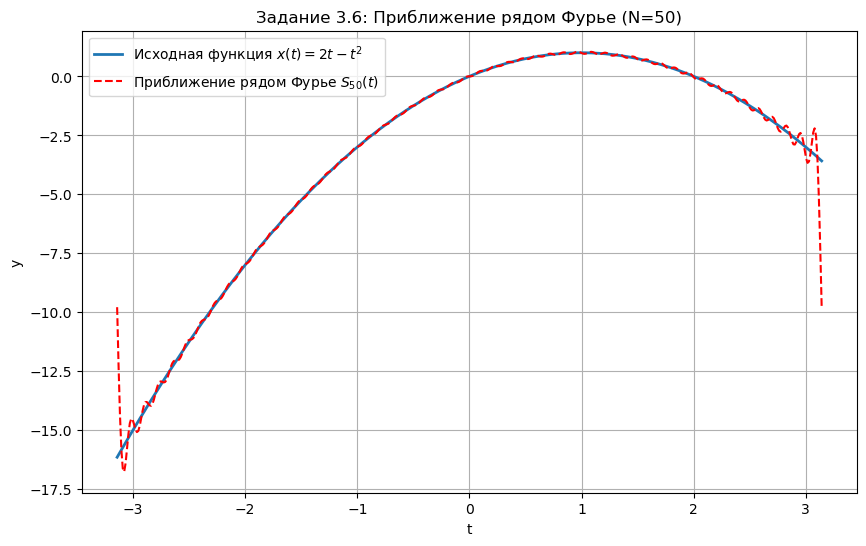

In [11]:
def task_3_6_corrected():
    print("\n--- Задание 3.6 (Исправленная версия) ---")

    def x_t(t): 
        return 2 * t - t**2
        
    def SN_t(t, N):
        # Корректный свободный член a0/2 = -π²/3
        s = -np.pi**2 / 3
        for k in range(1, N + 1):
            ak = 4 * ((-1)**(k + 1)) / (k**2)
            bk = 4 * ((-1)**(k + 1)) / k
            s += ak * np.cos(k * t) + bk * np.sin(k * t)
        return s

    t_vals = np.linspace(-np.pi, np.pi, 500)
    x_vals = x_t(t_vals)
    N_for_plot = 50
    print(f"Для визуализации используется N = {N_for_plot} членов ряда.")
    p_vals = SN_t(t_vals, N_for_plot)
    
    mse = calculate_mse(x_vals, p_vals)
    print(f"MSE для N={N_for_plot}: {mse:.6f}") # Теперь результат должен совпадать
    
    plt.figure(figsize=(10, 6))
    plt.plot(t_vals, x_vals, label='Исходная функция $x(t) = 2t - t^2$', linewidth=2)
    plt.plot(t_vals, p_vals, label=f'Приближение рядом Фурье $S_{{{N_for_plot}}}(t)$', linestyle='--', color='red')
    plt.title(f'Задание 3.6: Приближение рядом Фурье (N={N_for_plot})')
    plt.xlabel('t')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()


task_3_6_corrected()